In [43]:
import torch

In [44]:
import torch
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [45]:
query=inputs[1] # journey (q)
attn_scores_2=torch.empty(inputs.shape[0]) # attention scores for each word in the input
for i,x_i in enumerate(inputs):
    attn_scores_2[i]=torch.dot(query,x_i) # dot product of query and each input word (k)
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [46]:
# normalzation of attn scores so that they sum to 1
attn_weights_2_tmp=attn_scores_2/attn_scores_2.sum()
print("attention weights:", attn_weights_2_tmp)
print("sum of attention weights:", attn_weights_2_tmp.sum())

attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
sum of attention weights: tensor(1.0000)


In [47]:
# normalize the attention scores using softmax
def softmax_naive(x):
    return torch.exp(x)/torch.exp(x).sum()
attn_weights_2=softmax_naive(attn_scores_2)
print("attention weights:", attn_weights_2)
print("sum of attention weights:", attn_weights_2.sum())

attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
sum of attention weights: tensor(1.)


In [48]:
# using PyTorch's built-in softmax function
attn_weights_2=torch.softmax(attn_scores_2, dim=0)
print("attention weights:", attn_weights_2)
print("sum of attention weights:", attn_weights_2.sum())


attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
sum of attention weights: tensor(1.)


In [49]:
# creating context vector as weighted sum of input word vectors
query=inputs[1] # journey (q)
context_vec_2=torch.zeros(inputs.shape[1])
for i,x_i in enumerate(inputs):
    context_vec_2+=attn_weights_2[i]*x_i # weighted sum of input word vectors (v)
print("context vector:", context_vec_2)

context vector: tensor([0.4419, 0.6515, 0.5683])


In [50]:
# computing attention scores for all queries in the input
attn_scores=torch.empty(6, 6) # attention scores for all queries and keys
for i,x_i in enumerate(inputs):
    for j,x_j in enumerate(inputs):
        attn_scores[i,j]=torch.dot(x_i,x_j) # dot product of query and key
print("attention scores for all queries and keys:\n", attn_scores)

attention scores for all queries and keys:
 tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [51]:
# attn_weights
attn_weights=torch.softmax(attn_scores, dim=1) # softmax over keys for each query
print("attention weights for all queries and keys:\n", attn_weights)

attention weights for all queries and keys:
 tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [52]:
attn_weights.sum(dim=1) # sum of attention weights for each query should be 1

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [53]:
# creating context vector as weighted sum of input word vectors
all_context_vecs=attn_weights@inputs # matrix multiplication of attention weights and input word vectors
print("context vectors for all queries:\n", all_context_vecs)

context vectors for all queries:
 tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


 Implementing self-attention with trainable weights

In [54]:
x_2=inputs[1] # journey (x^2)
d_in=inputs.shape[1] # input dimension
d_out=2 # output dimension

In [55]:
# initializing weight matrices for query, key, and value transformations
torch.manual_seed(123)
W_query=torch.nn.Parameter(torch.randn(d_in, d_out),requires_grad=False) # weight matrix for query transformation
W_key=torch.nn.Parameter(torch.randn(d_in, d_out),requires_grad=False) # weight matrix for key transformation
W_value=torch.nn.Parameter(torch.randn(d_in, d_out),requires_grad=False) # weight matrix for value transformation

In [56]:
# next we compute the query, key, and value vectors for the input word "journey" (x^2)
query_2=x_2@W_query # query vector for "journey"
key_2=x_2@W_key # key vector for "journey"
value_2=x_2@W_value # value vector for "journey"
print("query vector for 'journey':", query_2)

query vector for 'journey': tensor([-1.1729, -0.0048])


In [57]:
keys=inputs@W_key # key vectors for all input words
values=inputs@W_value # value vectors for all input words1
print("key vectors for all input words:\n", keys)
print("value vectors for all input words:\n", values)

key vectors for all input words:
 tensor([[-0.1823, -0.6888],
        [-0.1142, -0.7676],
        [-0.1443, -0.7728],
        [ 0.0434, -0.3580],
        [-0.6467, -0.6476],
        [ 0.3262, -0.3395]])
value vectors for all input words:
 tensor([[ 0.1196, -0.3566],
        [ 0.4107,  0.6274],
        [ 0.4091,  0.6390],
        [ 0.2436,  0.4182],
        [ 0.2653,  0.6668],
        [ 0.2728,  0.3242]])


In [58]:
# lets compute attention scores for "journey" w22
key_2=keys[1]
attn_score_22=query_2.dot(key_2) # dot product of query and key for "journey"
print("attention score for 'journey' with itself:", attn_score_22)

attention score for 'journey' with itself: tensor(0.1376)


In [59]:
# computing attention scores using the query vector for "journey" and the key vectors for all input words
attn_scores_2=query_2@keys.T # matrix multiplication of query vector and key vectors
print("attention scores for 'journey' with all input words:\n", attn_scores_2)

attention scores for 'journey' with all input words:
 tensor([ 0.2172,  0.1376,  0.1730, -0.0491,  0.7616, -0.3809])


In [60]:
d_k=keys.shape[-1]
attn_weights_2=torch.softmax(attn_scores_2/d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1704, 0.1611, 0.1652, 0.1412, 0.2505, 0.1117])


In [61]:
# computing context vector for "journey" as weighted sum of value vectors
context_vec_2=attn_weights_2@values
print("context vector for 'journey':", context_vec_2)

context vector for 'journey': tensor([0.2854, 0.4081])


A query is analogous to a search query in a database. It represents the current item (e.g., a word or token in a sentence) the model focuses on or tries to understand. The query is used to probe the other parts of the input sequence to determine how much attention to pay to them.

The key is like a database key used for indexing and searching. In the attention mechanism, each item in the input sequence (e.g., each word in a sentence) has an associated key. These keys are used to match the query.

The value in this context is similar to the value in a key-value pair in a database. It represents the actual content or representation of the input items. Once the model determines which keys (and thus which parts of the input) are most relevant to the query (the current focus item), it retrieves the corresponding values.

In [62]:
# creating py class for self attention mechanism
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    def __init__(self,d_in,d_out):
        super().__init__()
        self.W_query=nn.Parameter(torch.rand(d_in, d_out))
        self.W_key=nn.Parameter(torch.rand(d_in, d_out))
        self.W_value=nn.Parameter(torch.rand(d_in, d_out))
    
    def forward(self,x):
        keys=x@self.W_key
        values=x@self.W_value
        queries=x@self.W_query
        attn_scores=queries@keys.T
        attn_weights=torch.softmax(
            attn_scores/keys.shape[-1]**0.5, dim=-1
        )
        context_vec=attn_weights@values
        return context_vec


In [63]:
torch.manual_seed(123)
sa_v1=SelfAttention_v1(d_in=3, d_out=2)
print(sa_v1(inputs))


tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


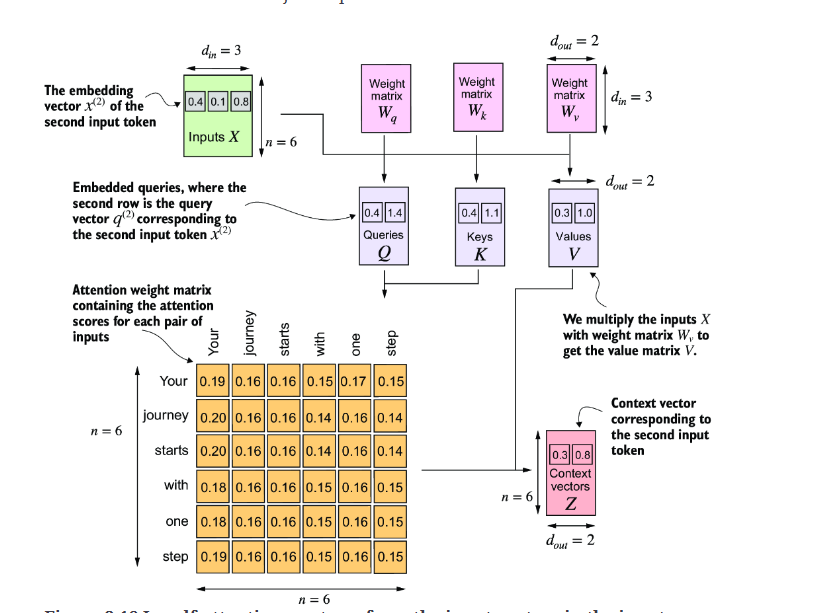